In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from scipy import stats
%matplotlib inline
sns.set(style = "darkgrid", font_scale = 1.5)
pd.set_option("display.max.columns", None)
pd.set_option("display.max.rows", None)

import warnings
warnings.filterwarnings("ignore")

C:\Users\hi\AppData\Local\Temp\ipykernel_8592\2802917846.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Health Indicators

Life expectancy → Average number of years a person is expected to live in that country for that year.

Adult Mortality → Probability of dying between ages 15 and 60 per 1000 population (higher means worse health outcomes).

infant deaths → Number of deaths of infants (age < 1 year) per 1000 population.

under-five deaths → Number of deaths of children under age 5 per 1000 population.

HIV/AIDS → Deaths per 1000 people due to HIV/AIDS.

thinness 1-19 years → Percentage of population aged 1–19 who are underweight.

thinness 5-9 years → Percentage of children aged 5–9 who are underweight.


## Immunization Coverage

Hepatitis B → Percentage of 1-year-old children immunized against Hepatitis B.

Polio → Percentage of 1-year-old children immunized against Polio.

Diphtheria → Percentage of 1-year-old children immunized against Diphtheria, Pertussis (whooping cough), and Tetanus (DPT).

Measles → Number of reported measles cases per 1000 population.


## Lifestyle / Health Expenditure

Alcohol → Per capita (average per person) consumption of alcohol in liters per year.

BMI → Average Body Mass Index of the population.

percentage expenditure → Expenditure on health as a percentage of GDP per capita.

Total expenditure → Government expenditure on health as a percentage of total government expenditure.


## Economy & Resources

GDP → Gross Domestic Product per capita (in USD).

Income composition of resources → Human Development Index (HDI)-like measure of income composition (values between 0 and 1, higher is better).

Schooling → Average number of years of schooling in the population.

Population → Population of the country for that year.

## Univariate Analysis (one variable at a time)
Goal: understand distributions, spread, and outliers.

### Numeric Variables (continuous like Life Expectancy, GDP, BMI, etc.):

- Histograms & KDE plots (distribution shape).  DONE

- Boxplots (detect outliers).  DONE

- Summary statistics (mean, median, std, skewness, kurtosis).  DONE

- Log-transform check (for skewed ones like GDP, population, measles cases).

### Categorical Variables (if you have region/country/year columns in dataset):

- Count plots. DONE

- Frequency tables (e.g., top 10 countries by population). DONE

In [2]:
df = pd.read_csv("data_life_expectancy.zip")
print(df.head(5))

       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   
3  Afghanistan  2012  Developing              59.5            272.0   
4  Afghanistan  2011  Developing              59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   \
0             62     0.01               71.279624         65.0      1154   
1             64     0.01               73.523582         62.0       492   
2             66     0.01               73.219243         64.0       430   
3             69     0.01               78.184215         67.0      2787   
4             71     0.01                7.097109         68.0      3013   

    BMI   under-five deaths   Polio  Total expenditure  Diphtheria   \
0   19.1                  83    6.0          

In [3]:
# show me any 5 random samples
print(df.sample(5))

         Country  Year      Status  Life expectancy   Adult Mortality  \
1421  Kyrgyzstan  2004  Developing              67.1            218.0   
1278      Israel  2003  Developing              79.7             71.0   
895     Ethiopia  2002  Developing              53.2            369.0   
1404      Kuwait  2005  Developing              73.6              9.0   
2908      Zambia  2013  Developing              63.0            328.0   

      infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   \
1421              4     3.41                0.000000         99.0         8   
1278              1     2.32             1731.755747         98.0       124   
895             237     0.80               10.824526          NaN      3332   
1404              0     0.01              239.575139         99.0        10   
2908             29     2.41               20.623063         79.0        35   

       BMI   under-five deaths   Polio  Total expenditure  Diphtheria   \
1421   37.5 

In [4]:
# clean up column names: Use titles format in column names and strip empty spaces
print("df.columns(BEFORE):",list(df.columns))
df.columns = df.columns.str.strip().str.title()
print()

# Rename one column that has extra space
df.rename(columns = {
    "Thinness  1-19 Years" : "Thinness 1-19 Years",
    "Gdp": "GDP"
    }, 
    inplace = True
)
print("df.columns(AFTER) :",list(df.columns))

df.columns(BEFORE): ['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']

df.columns(AFTER) : ['Country', 'Year', 'Status', 'Life Expectancy', 'Adult Mortality', 'Infant Deaths', 'Alcohol', 'Percentage Expenditure', 'Hepatitis B', 'Measles', 'Bmi', 'Under-Five Deaths', 'Polio', 'Total Expenditure', 'Diphtheria', 'Hiv/Aids', 'GDP', 'Population', 'Thinness 1-19 Years', 'Thinness 5-9 Years', 'Income Composition Of Resources', 'Schooling']


In [5]:
# Lets find duplicate values and if found then remove them.

# step1: find the count of duplicate values
print(df.duplicated().sum())

# step2: I want to see the duplicate values
# Get only duplicate rows
duplicates = df[df.duplicated()]
print(duplicates)

# step3: Drop your duplicate values
df.drop_duplicates(inplace=True)

0
Empty DataFrame
Columns: [Country, Year, Status, Life Expectancy, Adult Mortality, Infant Deaths, Alcohol, Percentage Expenditure, Hepatitis B, Measles, Bmi, Under-Five Deaths, Polio, Total Expenditure, Diphtheria, Hiv/Aids, GDP, Population, Thinness 1-19 Years, Thinness 5-9 Years, Income Composition Of Resources, Schooling]
Index: []


In [6]:
# Write the clean data to new zip file that can be reused later.
# Define compression options for the ZIP archive
compression_opts = dict(method='zip', archive_name='Life Expectancy Data.csv')

# Save the DataFrame to a ZIP file containing 'Life Expectancy Data.csv'
df.to_csv('data_life_expectancy_clean.zip', index=False, compression=compression_opts)

In [7]:
print(df.info())

# observation: 
# - There are 2938 records in total
# - Some columns like "Life Expectancy", "Alcohol", etc are missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life Expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   Infant Deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   Percentage Expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  Bmi                              2904 non-null   float64
 11  Under-Five Deaths                2938 non-null   int64  
 12  Polio               

In [ ]:
# step1: Lets print the count of missing values
print(df.isnull().sum())

print("################")
# step2: I want to see the percent of missing values and missing values
# and put it in dataframe. 
# Count of missing values
missing_count = df.isnull().sum()

# Percentage of missing values
missing_percentage = (missing_count / len(df)) * 100

# Combine into one DataFrame for better display
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
})

print(missing_df)

# NOTE: Since this is just EDA, we are not going to do anything about missing values

In [8]:
# I want to know the descriptive stats of each numeric column
# print(df.describe())
print(df.describe().T)

# observation: 
# - from year column I see that I have data from 2000 to 2015
# - 

                                  count          mean           std  \
Year                             2938.0  2.007519e+03  4.613841e+00   
Life Expectancy                  2928.0  6.922493e+01  9.523867e+00   
Adult Mortality                  2928.0  1.647964e+02  1.242921e+02   
Infant Deaths                    2938.0  3.030395e+01  1.179265e+02   
Alcohol                          2744.0  4.602861e+00  4.052413e+00   
Percentage Expenditure           2938.0  7.382513e+02  1.987915e+03   
Hepatitis B                      2385.0  8.094046e+01  2.507002e+01   
Measles                          2938.0  2.419592e+03  1.146727e+04   
Bmi                              2904.0  3.832125e+01  2.004403e+01   
Under-Five Deaths                2938.0  4.203574e+01  1.604455e+02   
Polio                            2919.0  8.255019e+01  2.342805e+01   
Total Expenditure                2712.0  5.938190e+00  2.498320e+00   
Diphtheria                       2919.0  8.232408e+01  2.371691e+01   
Hiv/Ai

In [9]:
# Now I want to see the stats on non-numeric,i.e. categorical columns:
print(df.describe(include = ['object']).T)

# observation:
# - There are total of 193 unique countries
# - Afghanistan is most occuring value in column country with frequency 16
# - Status column has 2 unique values. The value Developing is the most common occuring value with freq = 2426
# - Most countries are developing

        count unique          top  freq
Country  2938    193  Afghanistan    16
Status   2938      2   Developing  2426


Country                              0
Year                                 0
Status                               0
Life Expectancy                     10
Adult Mortality                     10
Infant Deaths                        0
Alcohol                            194
Percentage Expenditure               0
Hepatitis B                        553
Measles                              0
Bmi                                 34
Under-Five Deaths                    0
Polio                               19
Total Expenditure                  226
Diphtheria                          19
Hiv/Aids                             0
GDP                                448
Population                         652
Thinness 1-19 Years                 34
Thinness 5-9 Years                  34
Income Composition Of Resources    167
Schooling                          163
dtype: int64
################
                                 Missing Count  Missing Percentage
Country                                      

In [12]:
# Lets create a df that contains numeric values
df_numeric = df.select_dtypes(include = [np.number])
print(df_numeric.head(5))

   Year  Life Expectancy  Adult Mortality  Infant Deaths  Alcohol  \
0  2015             65.0            263.0             62     0.01   
1  2014             59.9            271.0             64     0.01   
2  2013             59.9            268.0             66     0.01   
3  2012             59.5            272.0             69     0.01   
4  2011             59.2            275.0             71     0.01   

   Percentage Expenditure  Hepatitis B  Measles   Bmi  Under-Five Deaths  \
0               71.279624         65.0     1154  19.1                 83   
1               73.523582         62.0      492  18.6                 86   
2               73.219243         64.0      430  18.1                 89   
3               78.184215         67.0     2787  17.6                 93   
4                7.097109         68.0     3013  17.2                 97   

   Polio  Total Expenditure  Diphtheria  Hiv/Aids         GDP  Population  \
0    6.0               8.16        65.0       0.1  

In [13]:
# Lets create a df that contains categorical values
df_categ = df.select_dtypes(include = ['object'])
print(df_categ.head(5))

       Country      Status
0  Afghanistan  Developing
1  Afghanistan  Developing
2  Afghanistan  Developing
3  Afghanistan  Developing
4  Afghanistan  Developing


# KDE plot

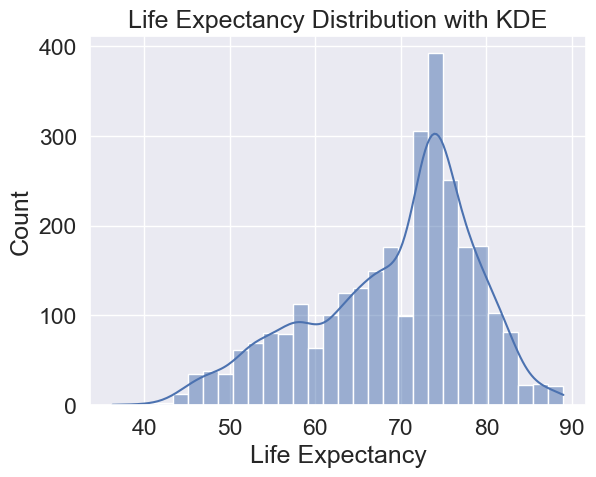

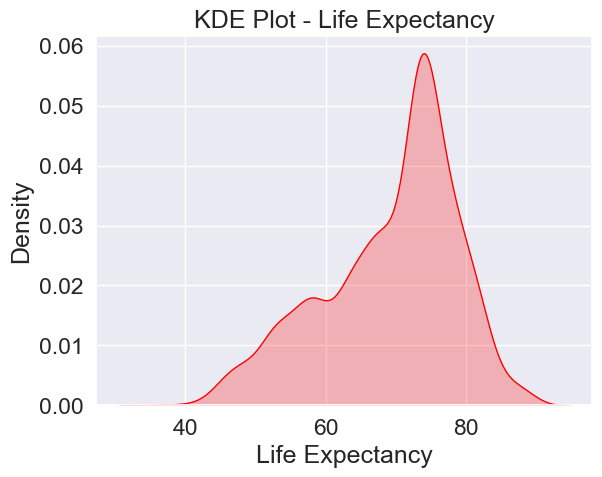

In [17]:
# Lets do KDE for only 1 feature: Life Expectancy
col = 'Life Expectancy'

# Histogram + KDE overlay
sns.histplot(df_numeric[col], bins=30, kde=True)
plt.title('Life Expectancy Distribution with KDE')
plt.show()

# or only KDE
sns.kdeplot(df[col], fill=True, color='red')
plt.title('KDE Plot - Life Expectancy')
plt.show()

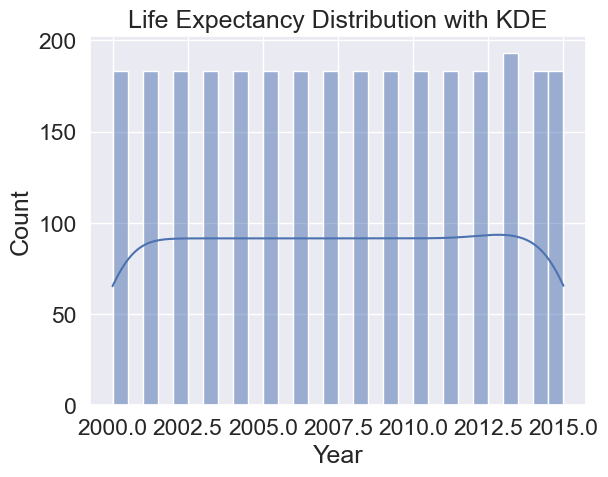

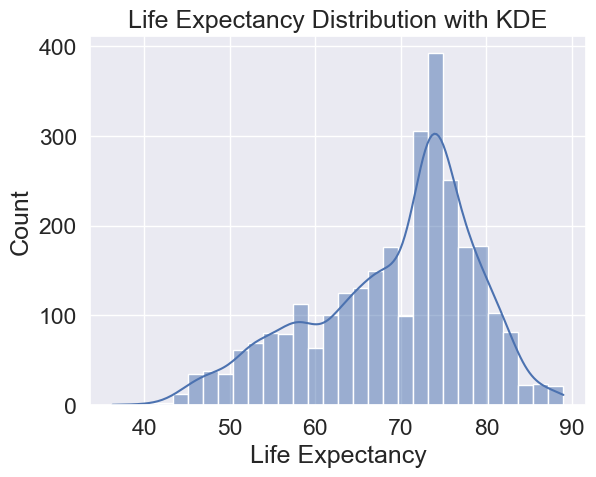

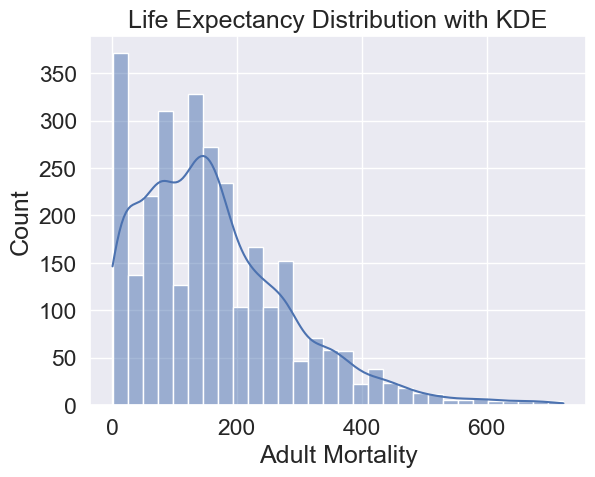

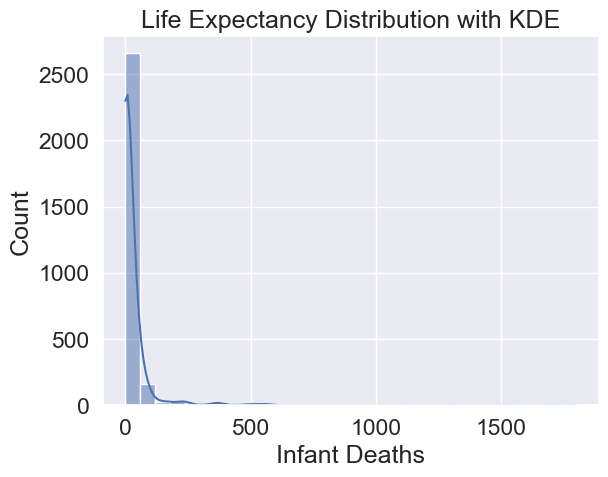

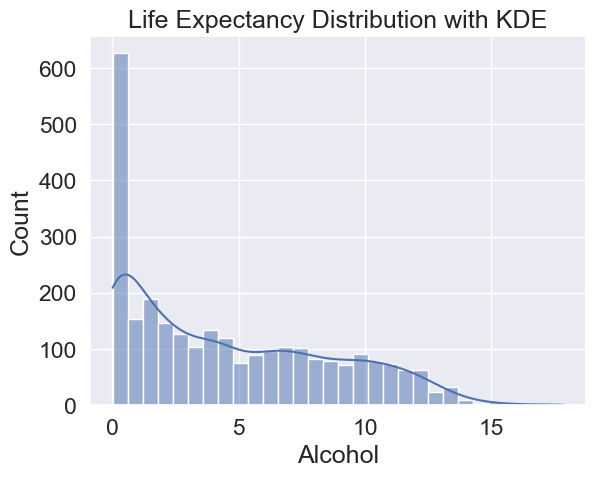

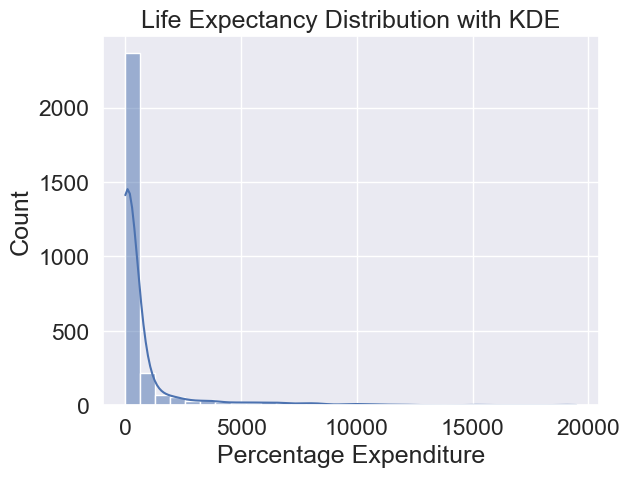

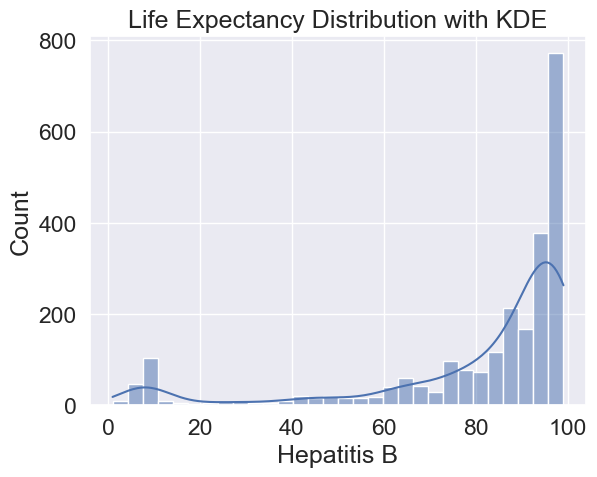

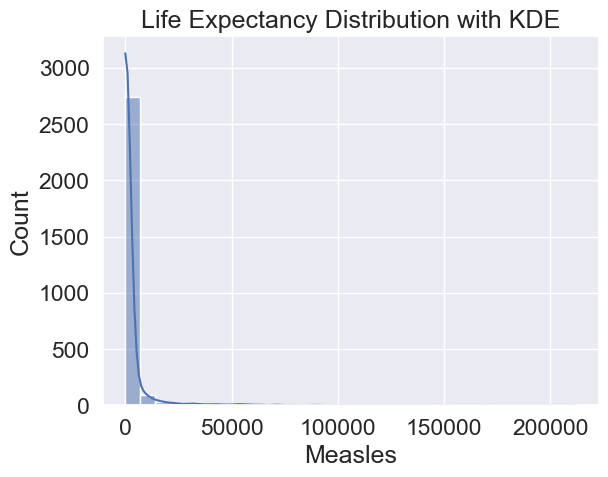

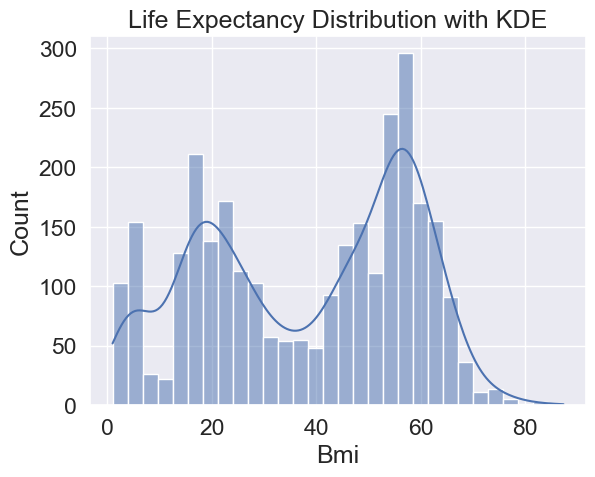

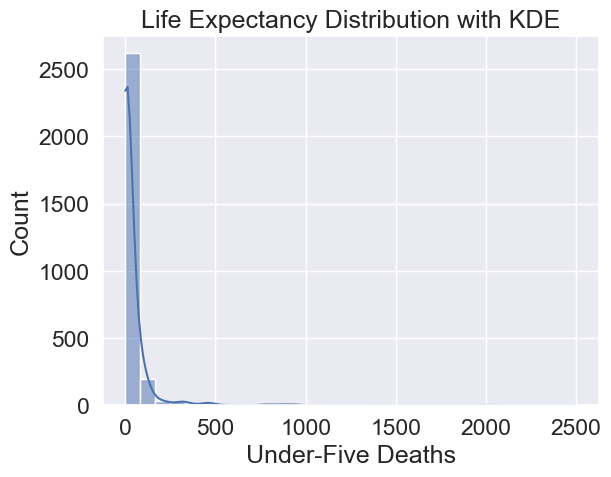

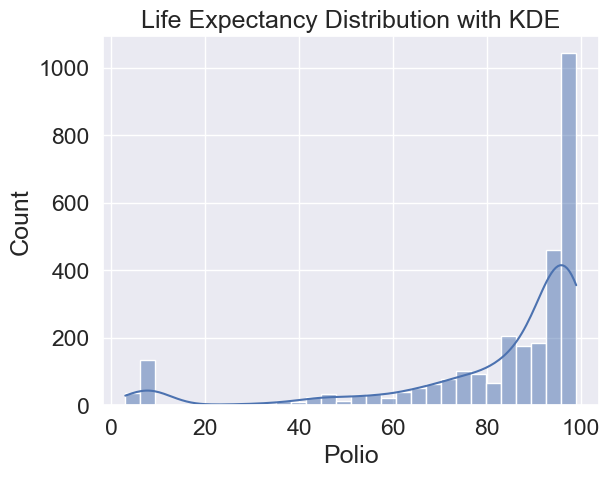

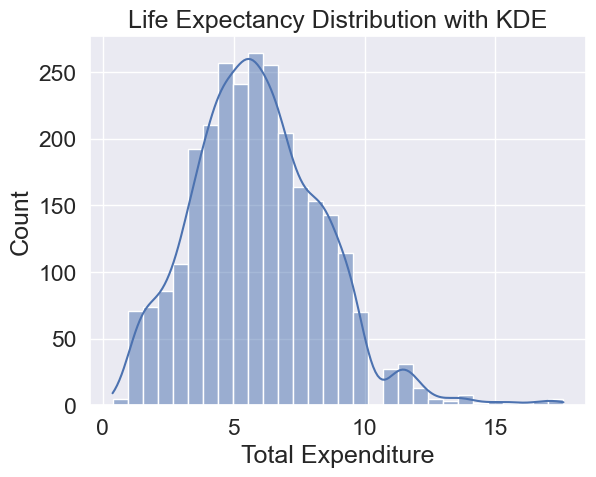

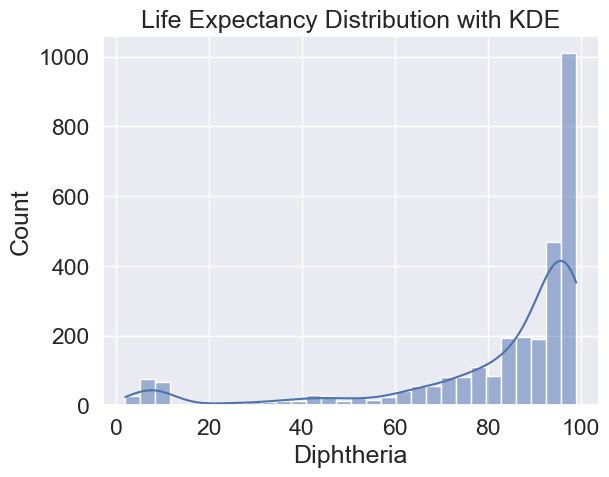

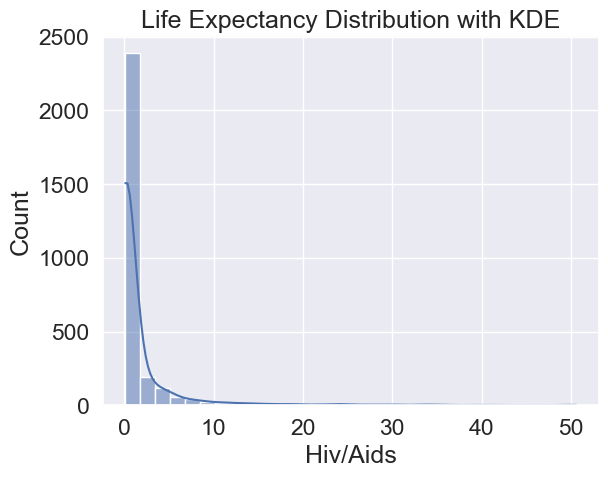

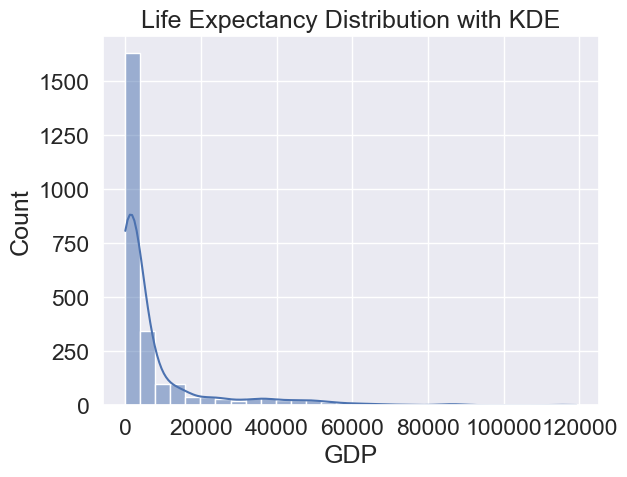

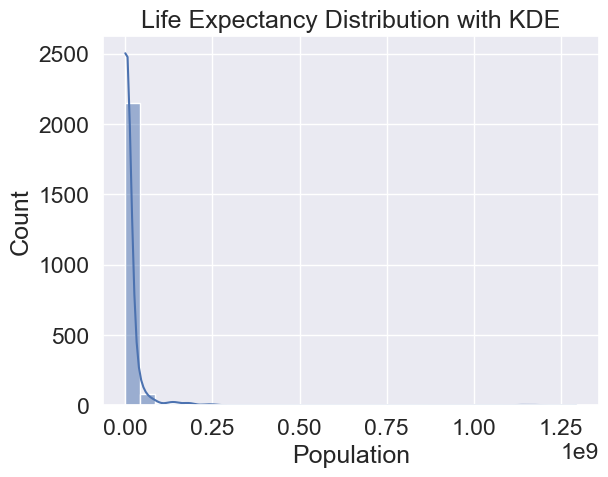

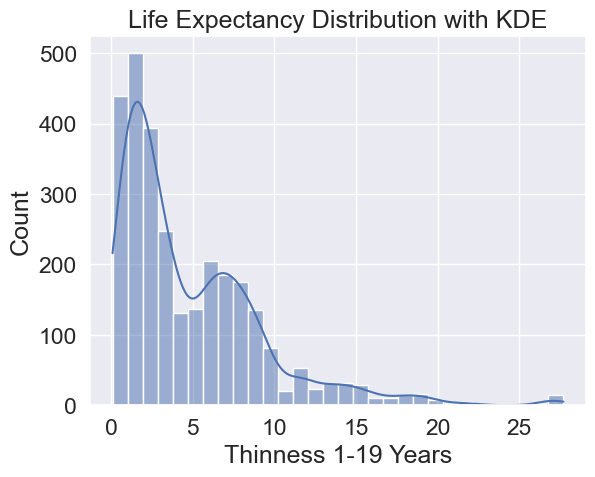

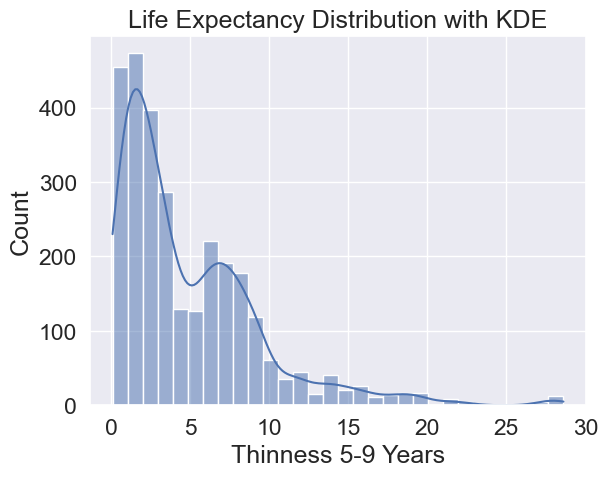

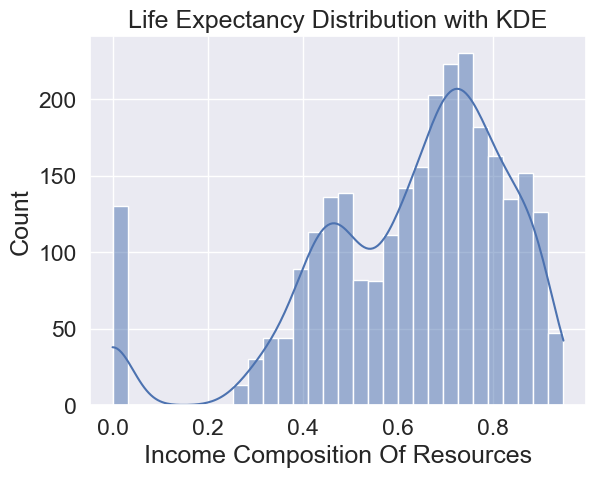

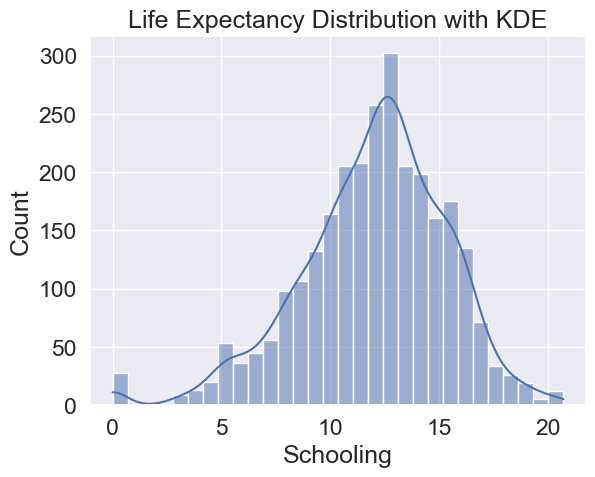

In [19]:
# step2: lets do KDE for all numeric columns
print("col_names:",df_numeric.columns)

for col in df_numeric.columns:
    # Histogram + KDE overlay
    sns.histplot(df_numeric[col], bins=30, kde=True)
    plt.show()


### Box plot

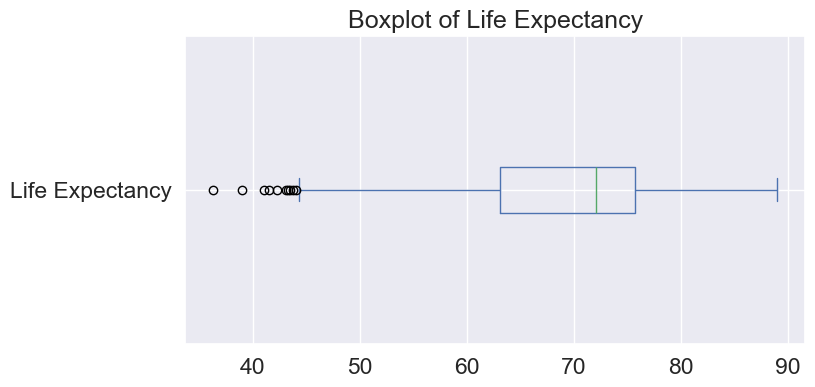

In [26]:
# boxplot
# step1: lets do single col first
col = 'Life Expectancy'

# Example: Boxplot of Life Expectancy
df_numeric[col].plot(kind='box', vert=False, figsize=(8,4))
plt.title(f'Boxplot of {col}')
plt.show()

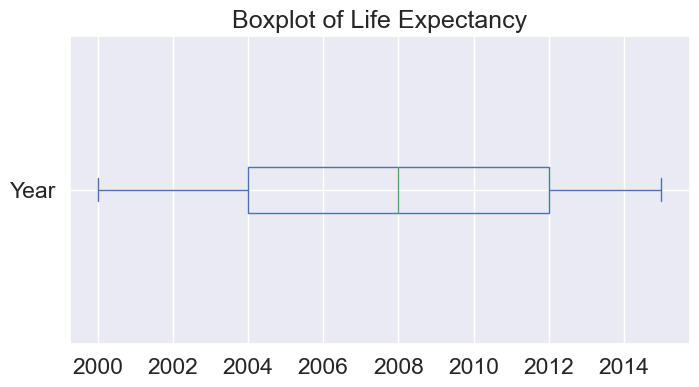

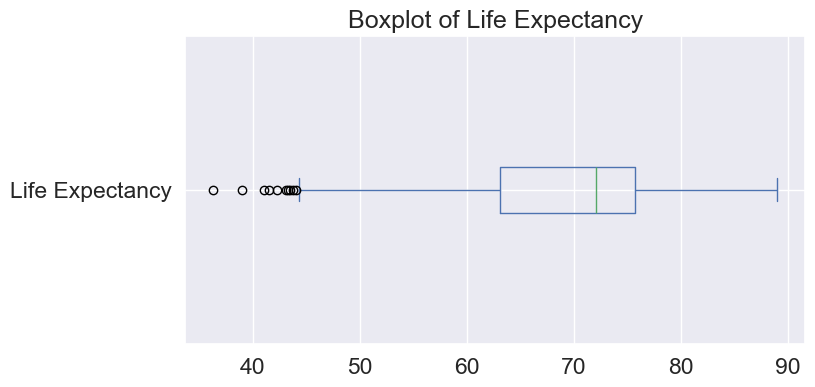

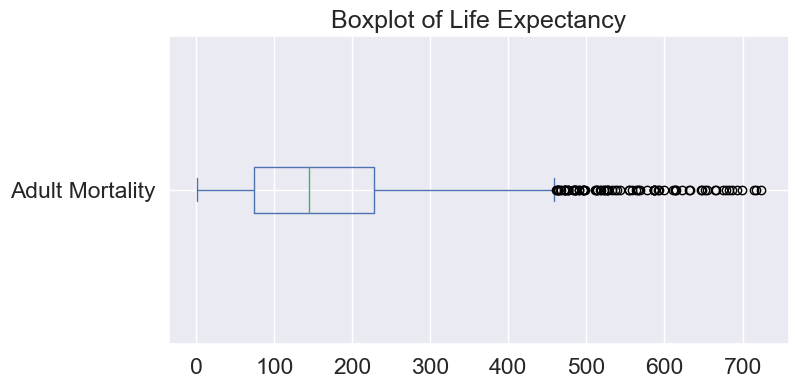

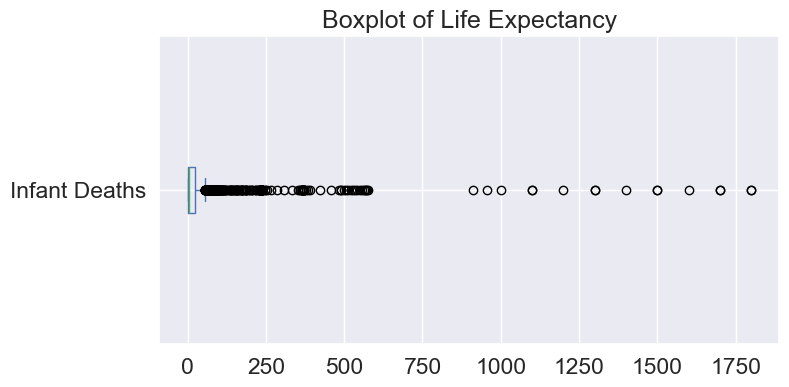

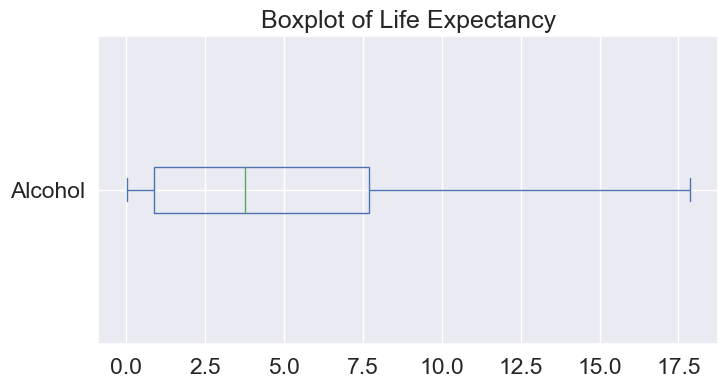

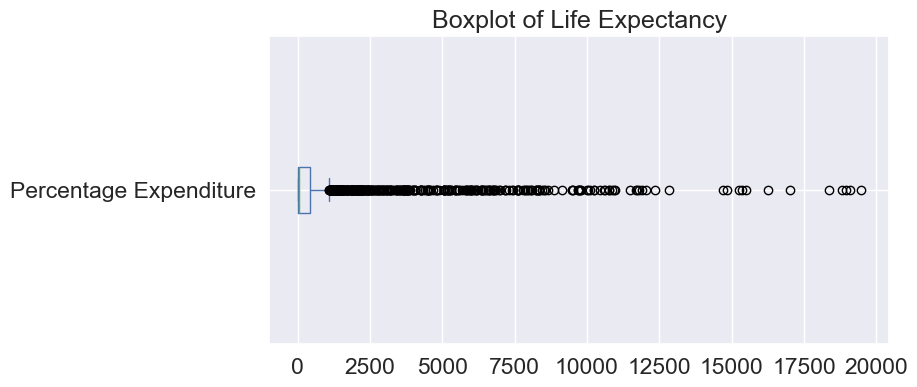

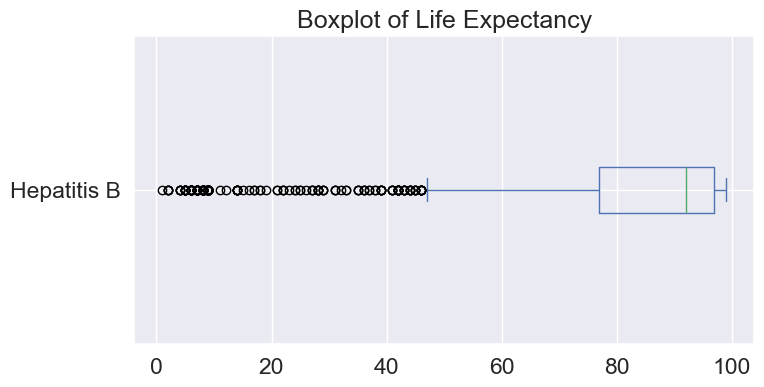

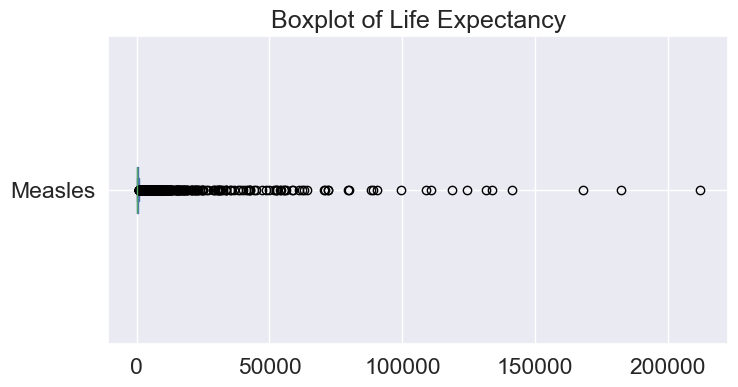

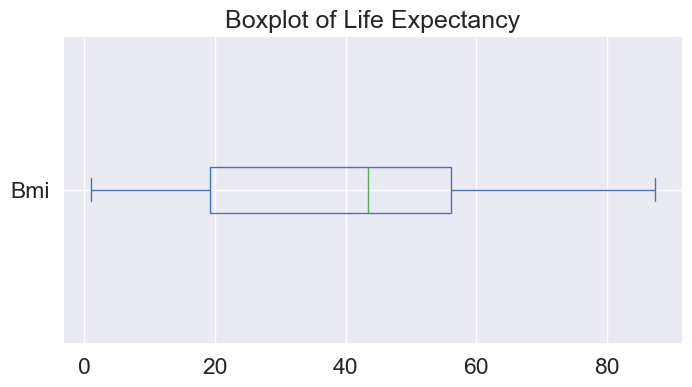

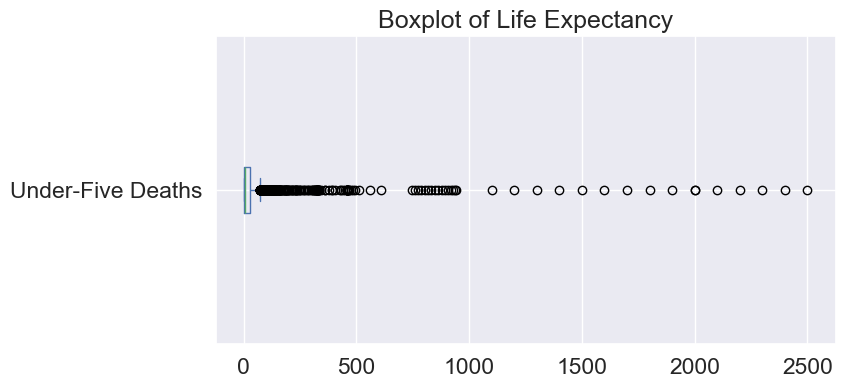

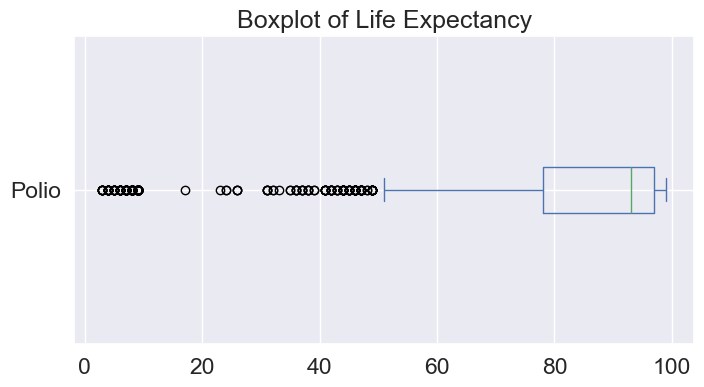

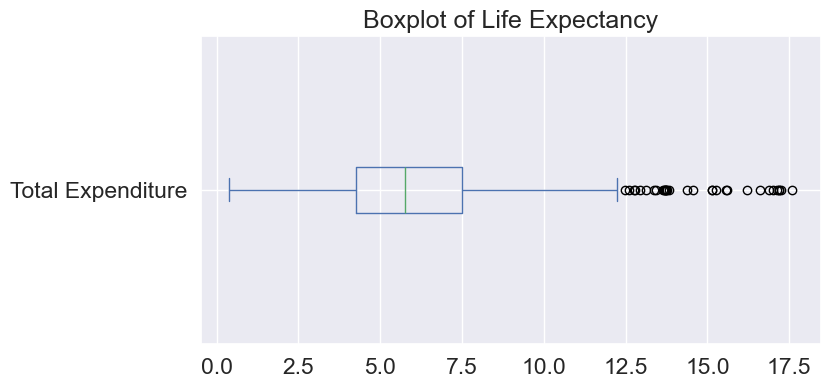

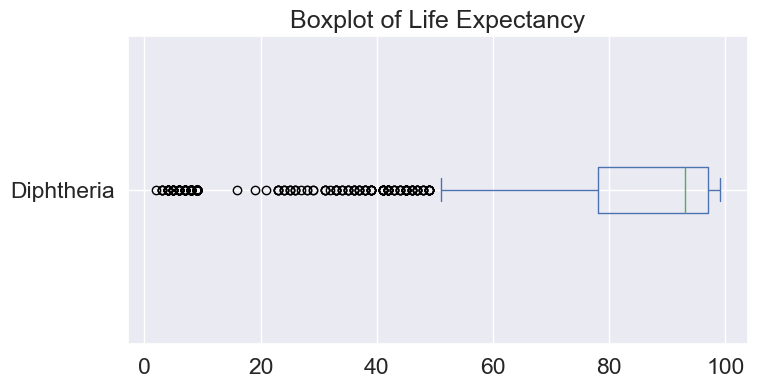

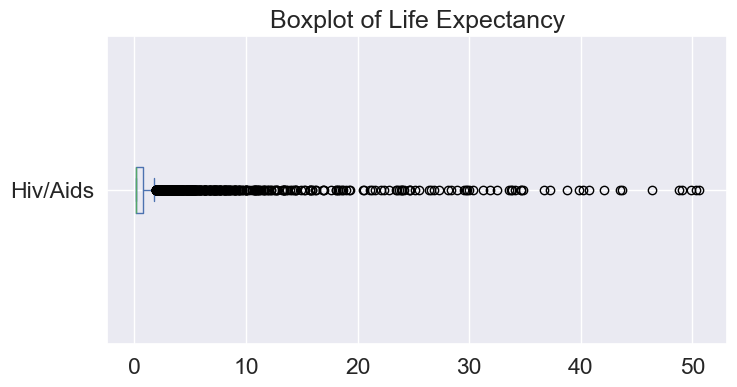

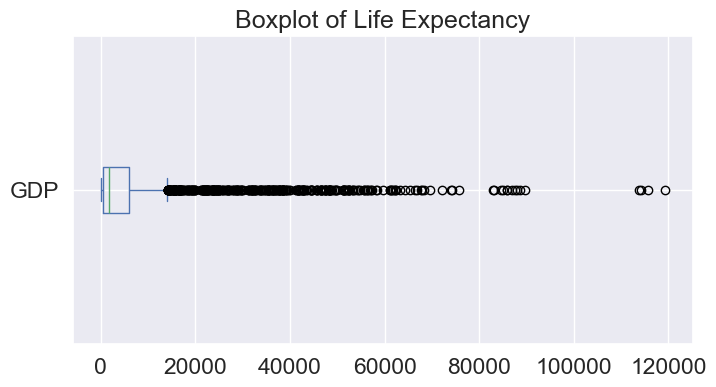

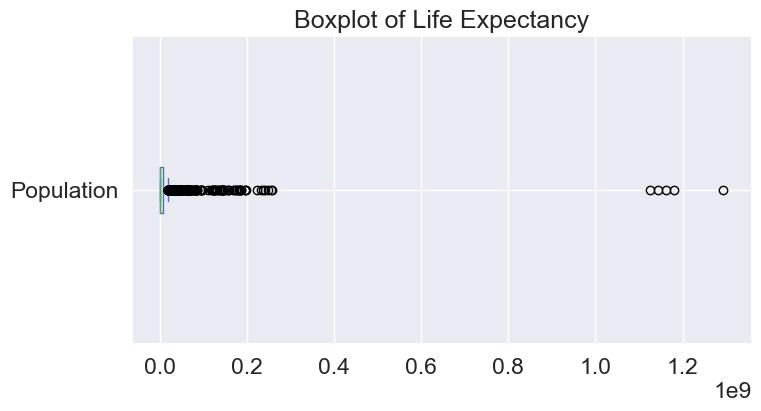

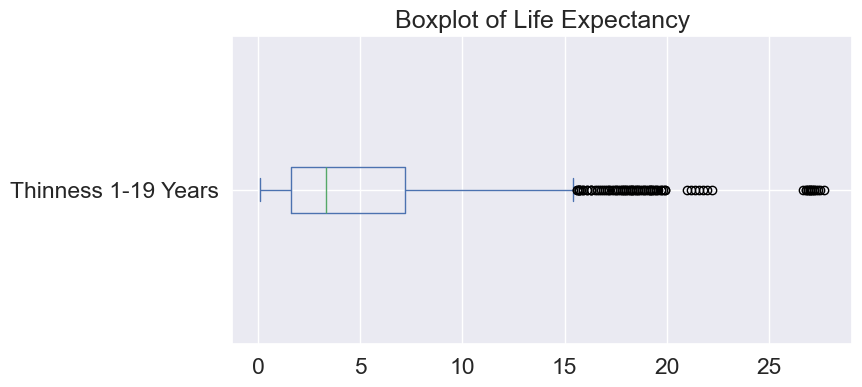

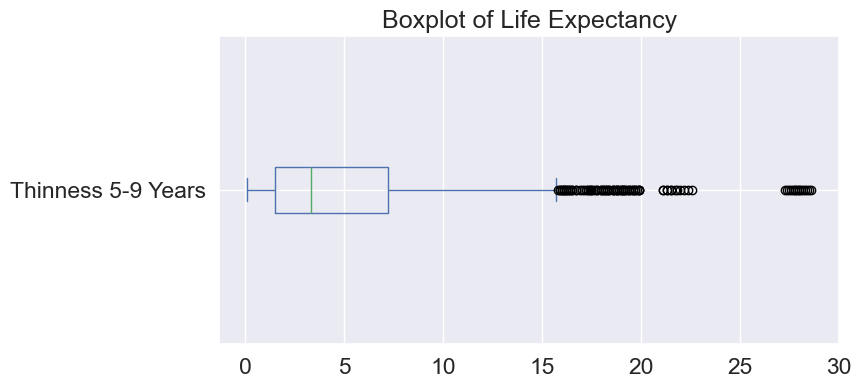

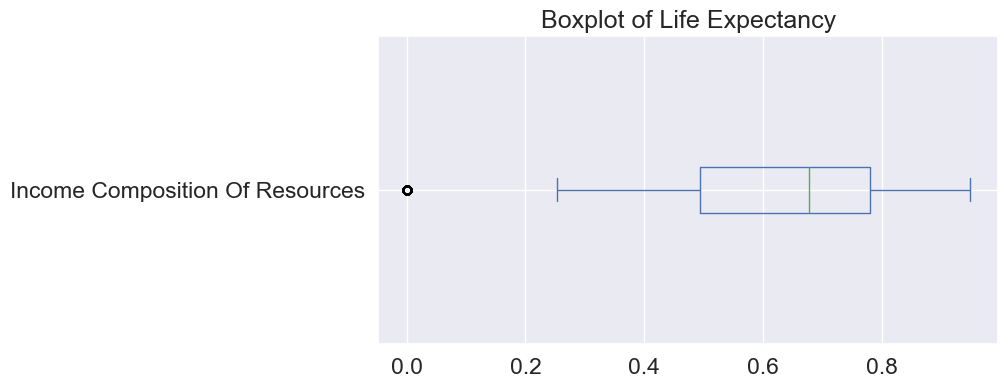

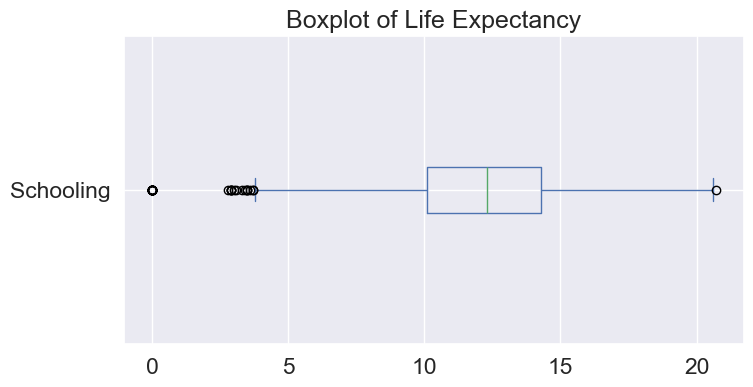

In [27]:
# step2: lets do for all columns

for col in df_numeric.columns:
    df_numeric[col].plot(kind='box', vert=False, figsize=(8,4))
    plt.title(f'Boxplot of {col}')
    plt.show()

In [24]:
## step3: Now lets print all outliers
for col in  df_numeric.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    df_outliers = df[(df[col] < (Q1 - 1.5 * IQR)) |
                  (df[col] > (Q3 + 1.5 * IQR))]
    
    print(f"Number of outliers for {col}: {len(df_outliers)}")
    print(df_outliers[[col]].head())
    print("---------------\n\n")


Number of outliers: 0
Empty DataFrame
Columns: [Year]
Index: []
---------------


Number of outliers: 10
      Life Expectancy
1127             36.3
1583             44.0
1584             43.5
1585             43.1
2307             43.3
---------------


Number of outliers: 82
     Adult Mortality
345            491.0
346            566.0
347            652.0
348            693.0
349            699.0
---------------


Number of outliers: 315
   Infant Deaths
0             62
1             64
2             66
3             69
4             71
---------------


Number of outliers: 0
Empty DataFrame
Columns: [Alcohol]
Index: []
---------------


Number of outliers: 389
    Percentage Expenditure
65             2422.999774
66             1991.430372
67             2156.229842
68             1810.875316
69             1983.956937
---------------


Number of outliers: 254
     Hepatitis B
40           9.0
41           8.0
87           9.0
142         44.0
143         33.0
---------------


N

## summary statistics

In [29]:
# Step1: summary stats for one column

col = 'Life Expectancy'
print("Mean:", df[col].mean())
print("Median:", df[col].median())
print("Std Dev:", df[col].std())
print("Skewness:", df[col].skew())
print("Kurtosis:", df[col].kurt())

Mean: 69.22493169398908
Median: 72.1
Std Dev: 9.523867487824301
Skewness: -0.6386047358773552
Kurtosis: -0.23447739417967428


In [31]:
# step2: now we do for all columns

summary_stats = pd.DataFrame({
    "Mean": df_numeric.mean(),
    "Median": df_numeric.median(),
    "Std Dev": df_numeric.std(),
    "Skewness": df_numeric.skew(),
    "Kurtosis": df_numeric.kurt()
})

print(summary_stats)
# print(summary_stats.T)


                                         Mean        Median       Std Dev  \
Year                             2.007519e+03  2.008000e+03  4.613841e+00   
Life Expectancy                  6.922493e+01  7.210000e+01  9.523867e+00   
Adult Mortality                  1.647964e+02  1.440000e+02  1.242921e+02   
Infant Deaths                    3.030395e+01  3.000000e+00  1.179265e+02   
Alcohol                          4.602861e+00  3.755000e+00  4.052413e+00   
Percentage Expenditure           7.382513e+02  6.491291e+01  1.987915e+03   
Hepatitis B                      8.094046e+01  9.200000e+01  2.507002e+01   
Measles                          2.419592e+03  1.700000e+01  1.146727e+04   
Bmi                              3.832125e+01  4.350000e+01  2.004403e+01   
Under-Five Deaths                4.203574e+01  4.000000e+00  1.604455e+02   
Polio                            8.255019e+01  9.300000e+01  2.342805e+01   
Total Expenditure                5.938190e+00  5.755000e+00  2.498320e+00   

### Now we deal with categorical columns

In [37]:
# give me the value count for column Country
print(df['Country'].value_counts())
print("##################")
# df['Country'].value_counts(normalize=True) * 100


Country
Afghanistan                                             16
Peru                                                    16
Nicaragua                                               16
Niger                                                   16
Nigeria                                                 16
Norway                                                  16
Oman                                                    16
Pakistan                                                16
Panama                                                  16
Papua New Guinea                                        16
Paraguay                                                16
Philippines                                             16
Lebanon                                                 16
Poland                                                  16
Portugal                                                16
Qatar                                                   16
Republic of Korea                               

Country
Afghanistan                                             0.544588
Peru                                                    0.544588
Nicaragua                                               0.544588
Niger                                                   0.544588
Nigeria                                                 0.544588
Norway                                                  0.544588
Oman                                                    0.544588
Pakistan                                                0.544588
Panama                                                  0.544588
Papua New Guinea                                        0.544588
Paraguay                                                0.544588
Philippines                                             0.544588
Lebanon                                                 0.544588
Poland                                                  0.544588
Portugal                                                0.544588
Qatar            

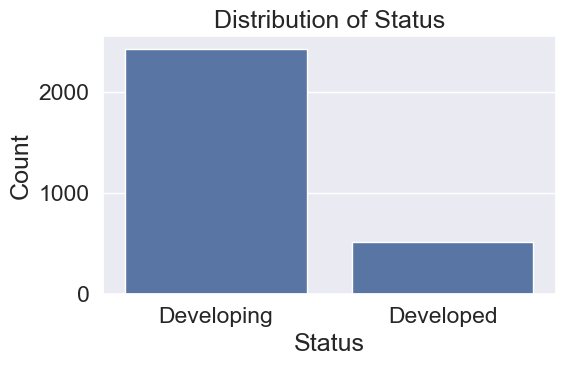

In [28]:
# Step1: lets plot countplot of column Status.
plt.figure(figsize = (6,4))
sns.countplot(x='Status', data=df_categ)
plt.xlabel("Status")
plt.ylabel("Count")
plt.title("Distribution of Status")
plt.tight_layout()
plt.show()

In [ ]:
# step2: Now I want to see the percentage
plt.figure(figsize=(6,4))

sns.countplot(x='Status', data=categorical_df, stat="percent")  # <-- normalize here

plt.xlabel("Status")
plt.ylabel("Percentage")
plt.title("Distribution of Status (in %)")
plt.tight_layout()
plt.show()

# observation: Developing countries are more compared to the Developed Nation

In [32]:
# Show me Top 10 countries by population

# step1: Top 10 countries by population
top10_pop = df.groupby('Country')['Population'].sum().sort_values(ascending=False).head(10)
print(top10_pop)


Country
India                 6.743483e+09
Indonesia             1.864884e+09
Brazil                1.410049e+09
Nigeria               1.134032e+09
Pakistan              1.104447e+09
Russian Federation    9.561934e+08
Ethiopia              7.032122e+08
Bangladesh            6.877626e+08
Germany               6.201176e+08
Philippines           5.962464e+08
Name: Population, dtype: float64


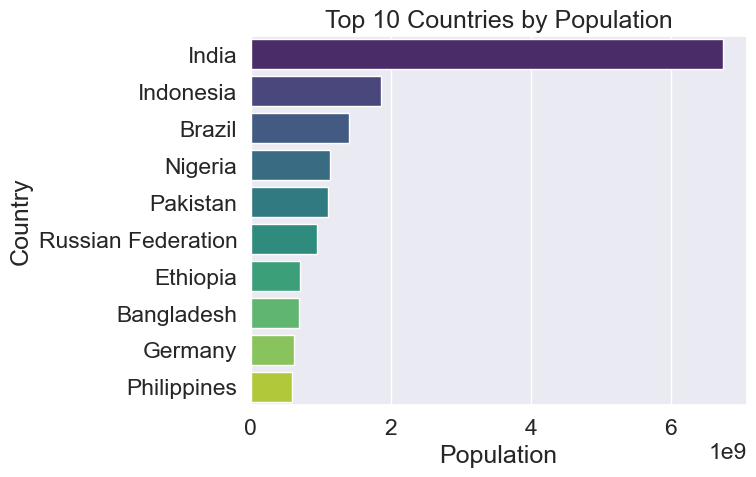

In [35]:
# step2: visualize above
top10_pop_df = df.groupby('Country')['Population'].sum().sort_values(ascending=False).head(10).reset_index()

sns.barplot(x='Population', y='Country', data=top10_pop_df, palette='viridis')
plt.title('Top 10 Countries by Population')
plt.show()


In [ ]:
# step3: I want to see population  of China
print(df.groupby('Country')['Population'].sum().loc['China'])

In [ ]:
## TO BE CONTINUED.....